# Hierarchical VAE for Emergent Representation Learning

**Complete training and analysis pipeline – Kaggle / Colab compatible**

This notebook trains a Hierarchical Variational Autoencoder (HVAE) on synthetic
genomic data to explore emergent latent representations.

---

## Setup checklist
- **GPU:** Enable GPU accelerator (Kaggle → Settings → Accelerator = GPU T4;  
  Colab → Runtime → Change runtime type → T4 GPU)
- **Runtime:** ~2–3 hours for 50 epochs on GPU; ~20× slower on CPU

---

## Contents
1. Environment setup & dependency installation  
2. DNA encoder / decoder utilities  
3. Synthetic genome generation  
4. Genomic dataset class  
5. Hierarchical VAE model  
6. VAE loss & β-annealing schedule  
7. Data loaders  
8. Training loop  
9. Training visualisation  
10. Latent space extraction  
11. Intrinsic dimensionality (PCA)  
12. UMAP projections  
13. Clustering analysis  
14. Reconstruction quality  
15. Synthetic sequence generation  
16. Generation statistics  
17. Comprehensive summary report  
18. Save / download results


## Cell 1 – Detect runtime environment

In [1]:
import sys, os, subprocess

# ── Detect platform ──────────────────────────────────────────────────────────
IN_KAGGLE = os.path.exists("/kaggle/working")
IN_COLAB  = "google.colab" in sys.modules or "COLAB_GPU" in os.environ

PLATFORM = "Kaggle" if IN_KAGGLE else ("Colab" if IN_COLAB else "Local/Other")
print(f"Platform : {PLATFORM}")
print(f"Python   : {sys.version.split()[0]}")

# ── GPU check ────────────────────────────────────────────────────────────────
result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                         "--format=csv,noheader"],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f"GPU      : {result.stdout.strip()}")
else:
    print("GPU      : not detected – training will be slow on CPU")


Platform : Colab
Python   : 3.12.13
GPU      : Tesla T4, 15360 MiB


## Cell 2 – Install / verify dependencies

In [2]:
import importlib, subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

# Packages that may be missing depending on the platform
REQUIRED = {
    "biopython"  : "Bio",
    "umap-learn" : "umap",
    "seaborn"    : "seaborn",
}

for pip_name, import_name in REQUIRED.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} …")
        _pip(pip_name)
    else:
        version = getattr(importlib.import_module(import_name), "__version__", "?")
        print(f"  ✓ {pip_name} {version}")

# Core packages – already present on both Kaggle and Colab
import torch, numpy, matplotlib, sklearn
print(f"  ✓ PyTorch      {torch.__version__}")
print(f"  ✓ NumPy        {numpy.__version__}")
print(f"  ✓ matplotlib   {matplotlib.__version__}")
print(f"  ✓ scikit-learn {sklearn.__version__}")

if torch.cuda.is_available():
    print(f"\nGPU ready: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("\n⚠ No GPU – training will use CPU")


Installing biopython …
  ✓ umap-learn 0.5.11
  ✓ seaborn 0.13.2
  ✓ PyTorch      2.10.0+cu128
  ✓ NumPy        2.0.2
  ✓ matplotlib   3.10.0
  ✓ scikit-learn 1.6.1

GPU ready: Tesla T4 (15.6 GB)


## Cell 3 – Import libraries

In [3]:
import os, math, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ── Machine-learning ──────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import umap  # umap-learn

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# ── BioPython ─────────────────────────────────────────────────────────────────
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✓ All libraries imported")


✓ All libraries imported


## Cell 4 – DNA encoder / decoder utilities

In [4]:
class DNAEncoder:
    """Convert between DNA sequences and one-hot numerical arrays."""

    BASE_TO_IDX = {"A": 0, "C": 1, "G": 2, "T": 3}
    IDX_TO_BASE = {0: "A", 1: "C", 2: "G", 3: "T"}

    @staticmethod
    def one_hot_encode(sequence: str) -> np.ndarray:
        """(4, L) float32 one-hot matrix; unknown bases → all-zeros column."""
        seq = sequence.upper()
        out = np.zeros((4, len(seq)), dtype=np.float32)
        for i, base in enumerate(seq):
            idx = DNAEncoder.BASE_TO_IDX.get(base)
            if idx is not None:
                out[idx, i] = 1.0
        return out

    @staticmethod
    def decode_one_hot(arr: np.ndarray) -> str:
        """(4, L) array → DNA string; ambiguous columns become 'N'."""
        seq = []
        for i in range(arr.shape[1]):
            col = arr[:, i]
            seq.append("N" if col.max() < 0.5
                        else DNAEncoder.IDX_TO_BASE[int(col.argmax())])
        return "".join(seq)

    @staticmethod
    def gc_content(sequence: str) -> float:
        """GC content as a percentage (0–100)."""
        s = sequence.upper()
        return (s.count("G") + s.count("C")) / max(len(s), 1) * 100.0


# ── sanity check ──────────────────────────────────────────────────────────────
_test = "ATCGATCGATCG"
assert DNAEncoder.decode_one_hot(DNAEncoder.one_hot_encode(_test)) == _test
print(f"✓ DNAEncoder round-trip OK  ({_test})")
print(f"  GC content: {DNAEncoder.gc_content(_test):.1f}%")


✓ DNAEncoder round-trip OK  (ATCGATCGATCG)
  GC content: 50.0%


## Cell 5 – Synthetic genome generation

In [5]:
def create_synthetic_genome(
    length: int = 5_000_000,
    output_file: str = "synthetic_genome.fasta",
    gc_content: float = 0.36,
    seed: int = SEED,
) -> str:
    """
    Generate a synthetic genome with realistic base composition.

    Parameters
    ----------
    length       : genome length in base pairs
    output_file  : output FASTA path
    gc_content   : target GC fraction (0.36 ≈ C. elegans)
    seed         : random seed for reproducibility

    Returns
    -------
    Path to the written FASTA file.
    """
    rng = np.random.default_rng(seed)  # use new Generator API (safer than global seed)

    gc_half = gc_content / 2.0
    at_half = (1.0 - gc_content) / 2.0
    probs   = [at_half, at_half, gc_half, gc_half]  # A, T, G, C

    print(f"Generating {length/1e6:.1f} Mb synthetic genome …")
    seq = "".join(rng.choice(["A", "T", "G", "C"], size=length, p=probs))

    record = SeqRecord(
        Seq(seq),
        id="chr1",
        description=f"Synthetic {length/1e6:.1f} Mb | target GC={gc_content:.1%}",
    )
    SeqIO.write(record, output_file, "fasta")

    actual_gc = DNAEncoder.gc_content(seq)
    print(f"✓ Written  : {output_file}")
    print(f"  Length   : {length:,} bp")
    print(f"  Actual GC: {actual_gc:.2f}%  (target {gc_content*100:.1f}%)")
    return output_file


GENOME_FILE = create_synthetic_genome(length=5_000_000, gc_content=0.36)


Generating 5.0 Mb synthetic genome …
✓ Written  : synthetic_genome.fasta
  Length   : 5,000,000 bp
  Actual GC: 35.98%  (target 36.0%)


## Cell 6 – Genomic dataset class

In [6]:
class GenomicDataset(Dataset):
    """
    PyTorch Dataset – sliding-window extraction from a FASTA file.

    Each item is a flattened (4 × window_size,) float32 one-hot tensor.
    """

    def __init__(
        self,
        fasta_file: str,
        window_size: int = 1024,
        stride: int = 512,
        max_samples: int | None = None,
        n_threshold: float = 0.10,
    ):
        self.window_size = window_size
        self.sequences: list[str] = []

        print(f"Loading sequences from {fasta_file} …")
        for record in SeqIO.parse(fasta_file, "fasta"):
            seq = str(record.seq).upper()
            for start in range(0, len(seq) - window_size + 1, stride):
                if max_samples and len(self.sequences) >= max_samples:
                    break
                chunk = seq[start : start + window_size]
                if chunk.count("N") / window_size <= n_threshold:
                    self.sequences.append(chunk)
            if max_samples and len(self.sequences) >= max_samples:
                break

        overlap_pct = (window_size - stride) / window_size * 100
        print(f"✓ Dataset  : {len(self.sequences):,} sequences")
        print(f"  Window   : {window_size} bp  |  stride {stride} bp  "
              f"({overlap_pct:.0f}% overlap)")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return torch.from_numpy(
            DNAEncoder.one_hot_encode(self.sequences[idx]).flatten()
        )

    def raw(self, idx: int) -> str:
        return self.sequences[idx]


dataset = GenomicDataset(
    fasta_file=GENOME_FILE,
    window_size=1024,
    stride=512,
    max_samples=100_000,
)

print(f"\nSample tensor shape : {dataset[0].shape}")
print(f"Sample sequence     : {dataset.raw(0)[:60]}…")


Loading sequences from synthetic_genome.fasta …
✓ Dataset  : 9,764 sequences
  Window   : 1024 bp  |  stride 512 bp  (50% overlap)

Sample tensor shape : torch.Size([4096])
Sample sequence     : GTCGACGGATTCGCTATACTGTCCGATAAGGCTTTAATAGTCGACGTAGAAAGGGGTTAA…


## Cell 7 – Hierarchical VAE model

### Architecture overview

```
Input (4096-d one-hot)
  │
  ├─ enc1 : 4096 → 2048   ← shared encoder trunk
  │    │
  │    ├─ enc2 : 2048 → 1024
  │    │    │
  │    │    └─ enc3 : 1024 → 512
  │    │         │
  │    │         └─ z1 (μ/logvar) : 256-d   ← most abstract
  │    │
  │    └─ z2 (μ/logvar) : 512-d             ← intermediate
  │
  └─ z3 (μ/logvar) : 1024-d                 ← fine details

z = [z1 ‖ z2 ‖ z3]  (1792-d)
  │
  ├─ dec1 : 1792 → 512
  │    └─ dec2 : 512 → 1024
  │         └─ dec3 : 1024 → 2048
  │              └─ output : 2048 → 4096
Output (4096-d reconstruction)
```


In [7]:
class HierarchicalVAE(nn.Module):
    """
    Multi-scale Variational Autoencoder with three hierarchical latent spaces.

    The three levels capture representations at different abstraction scales:
      z1 (256-d)  – global / most abstract (from deepest encoder layer)
      z2 (512-d)  – intermediate
      z3 (1024-d) – local / fine details   (from shallowest encoder layer)
    """

    def __init__(
        self,
        input_dim:   int        = 4096,
        latent_dims: list[int]  = None,
        dropout:     float      = 0.30,
    ):
        super().__init__()

        if latent_dims is None:
            latent_dims = [256, 512, 1024]

        self.input_dim   = input_dim
        self.latent_dims = latent_dims

        # ── Encoder ──────────────────────────────────────────────────────────
        def _block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.LayerNorm(out_f),
                nn.GELU(),
                nn.Dropout(dropout),
            )

        self.enc1 = _block(input_dim, 2048)   # 4096 → 2048
        self.enc2 = _block(2048,      1024)   # 2048 → 1024
        self.enc3 = _block(1024,       512)   # 1024 → 512

        # ── Latent projections ───────────────────────────────────────────────
        self.z1_mu,     self.z1_lv = nn.Linear(512,  latent_dims[0]), nn.Linear(512,  latent_dims[0])
        self.z2_mu,     self.z2_lv = nn.Linear(1024, latent_dims[1]), nn.Linear(1024, latent_dims[1])
        self.z3_mu,     self.z3_lv = nn.Linear(2048, latent_dims[2]), nn.Linear(2048, latent_dims[2])

        # ── Decoder ──────────────────────────────────────────────────────────
        total_z = sum(latent_dims)             # 1792

        self.dec1 = _block(total_z, 512)
        self.dec2 = _block(512,    1024)
        self.dec3 = _block(1024,   2048)
        self.out  = nn.Linear(2048, input_dim)

        self._init_weights()

    # ── weight init ──────────────────────────────────────────────────────────
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ── reparameterisation ───────────────────────────────────────────────────
    @staticmethod
    def reparam(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    # ── encode ───────────────────────────────────────────────────────────────
    def encode(self, x: torch.Tensor):
        h1 = self.enc1(x)    # (B, 2048)
        h2 = self.enc2(h1)   # (B, 1024)
        h3 = self.enc3(h2)   # (B,  512)

        z1_mu, z1_lv = self.z1_mu(h3), self.z1_lv(h3)
        z2_mu, z2_lv = self.z2_mu(h2), self.z2_lv(h2)
        z3_mu, z3_lv = self.z3_mu(h1), self.z3_lv(h1)

        z1 = self.reparam(z1_mu, z1_lv)
        z2 = self.reparam(z2_mu, z2_lv)
        z3 = self.reparam(z3_mu, z3_lv)

        latents = (z1, z2, z3)
        params  = [(z1_mu, z1_lv), (z2_mu, z2_lv), (z3_mu, z3_lv)]
        return latents, params

    # ── decode ───────────────────────────────────────────────────────────────
    def decode(self, latents) -> torch.Tensor:
        z = torch.cat(latents, dim=-1)   # (B, 1792)
        return self.out(self.dec3(self.dec2(self.dec1(z))))

    # ── forward ──────────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor):
        latents, params = self.encode(x)
        return self.decode(latents), latents, params

    # ── prior sampling ───────────────────────────────────────────────────────
    @torch.no_grad()
    def sample(self, n: int, device: str = "cpu", temperature: float = 1.0) -> torch.Tensor:
        self.eval()
        zs = tuple(
            torch.randn(n, d, device=device) * temperature
            for d in self.latent_dims
        )
        return self.decode(zs)


# ── instantiate & summarise ──────────────────────────────────────────────────
model = HierarchicalVAE(input_dim=4096, latent_dims=[256, 512, 1024], dropout=0.30)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(f"  Input dim      : {model.input_dim}")
print(f"  Latent dims    : {model.latent_dims}  (total {sum(model.latent_dims)})")
print(f"  Parameters     : {total_p:,}  (~{total_p*4/1e6:.1f} MB fp32)")
print(f"  Trainable      : {trainable_p:,}")
print("=" * 60)

# quick shape test
_x  = torch.randn(2, 4096)
_r, _l, _p = model(_x)
assert _r.shape == _x.shape, "Forward pass shape mismatch!"
print("✓ Forward-pass shape test passed")


MODEL SUMMARY
  Input dim      : 4096
  Latent dims    : [256, 512, 1024]  (total 1792)
  Parameters     : 28,471,808  (~113.9 MB fp32)
  Trainable      : 28,471,808
✓ Forward-pass shape test passed


## Cell 8 – VAE loss & β-annealing schedule

In [8]:
def vae_loss(recon, x, params, beta=1.0, kl_weights=None):
    """
    ELBO loss = reconstruction (MSE) + β × weighted KL divergence.

    Returns
    -------
    total_loss, recon_loss, kl_loss, kl_per_level  (all scalar tensors / floats)
    """
    if kl_weights is None:
        kl_weights = [1.0, 1.0, 1.0]

    # Reconstruction – sum over dims, mean over batch (consistent scaling)
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)

    kl_loss       = recon.new_zeros(1).squeeze()
    kl_per_level  = []

    for w, (mu, logvar) in zip(kl_weights, params):
        # Analytically: KL(N(μ,σ²) ‖ N(0,1)) = -0.5 Σ(1 + log σ² - μ² - σ²)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=-1).mean()
        kl_per_level.append(kl.item())
        kl_loss = kl_loss + w * kl

    return recon_loss + beta * kl_loss, recon_loss, kl_loss, kl_per_level


def beta_schedule(epoch: int, warmup: int = 15, max_beta: float = 1.0,
                  mode: str = "cosine") -> float:
    """
    β-annealing: ramp β from 0 → max_beta over `warmup` epochs.
    mode = 'linear' | 'cosine' | 'constant'
    """
    if mode == "constant" or epoch >= warmup:
        return max_beta
    progress = epoch / warmup
    if mode == "cosine":
        return max_beta * (1 - math.cos(progress * math.pi)) / 2
    return progress * max_beta   # linear


# ── smoke test ────────────────────────────────────────────────────────────────
_inp  = torch.randn(4, 4096)
_rec, _lat, _par = model(_inp)
_tl, _rl, _kl, _kll = vae_loss(_rec, _inp, _par, beta=0.5)
print(f"✓ Loss function OK")
print(f"  total={_tl.item():.3f}  recon={_rl.item():.3f}  "
      f"kl={_kl.item():.3f}  per-level={[f'{v:.2f}' for v in _kll]}")


✓ Loss function OK
  total=6328.638  recon=5744.738  kl=1167.799  per-level=['175.13', '349.03', '643.64']


## Cell 9 – Data loaders (train / val / test split)

In [9]:
BATCH_SIZE = 128

n_total = len(dataset)
n_train = int(0.80 * n_total)
n_val   = int(0.10 * n_total)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

# num_workers=2 works on both Kaggle and Colab; set to 0 if you hit
# "DataLoader worker exited unexpectedly" errors on some environments.
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

train_loader = DataLoader(train_ds, shuffle=True,  **_loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **_loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **_loader_kw)

print("=" * 60)
print("DATA LOADERS")
print("=" * 60)
print(f"  Train : {len(train_ds):,}  ({len(train_ds)/n_total*100:.0f}%)")
print(f"  Val   : {len(val_ds):,}   ({len(val_ds)/n_total*100:.0f}%)")
print(f"  Test  : {len(test_ds):,}   ({len(test_ds)/n_total*100:.0f}%)")
print(f"  Batch : {BATCH_SIZE}  → {len(train_loader):,} batches/epoch")
print("=" * 60)


DATA LOADERS
  Train : 7,811  (80%)
  Val   : 976   (10%)
  Test  : 977   (10%)
  Batch : 128  → 62 batches/epoch


## Cell 10 – Training function

In [10]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs:    int   = 50,
    lr:        float = 1e-3,
    device:    str   = "cuda",
    patience:  int   = 10,
    save_path: str   = "best_model.pth",
):
    """
    Train the HierarchicalVAE with AdamW, ReduceLROnPlateau, and early stopping.

    Returns
    -------
    history : dict with per-epoch loss/metric lists
    """
    model.to(device)

    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=0.5, patience=5, min_lr=1e-6
    )

    history = {k: [] for k in [
        "train_loss", "train_recon", "train_kl",
        "val_loss",   "val_recon",   "val_kl",
        "kl_l1", "kl_l2", "kl_l3",
        "beta", "lr",
    ]}

    best_val  = float("inf")
    pat_count = 0

    print("=" * 60)
    print(f"TRAINING  device={device.upper()}  epochs={epochs}  lr={lr}")
    print("=" * 60)

    for epoch in range(epochs):
        beta = beta_schedule(epoch, warmup=15, max_beta=1.0, mode="cosine")
        history["beta"].append(beta)
        history["lr"].append(optimiser.param_groups[0]["lr"])

        # ── train ────────────────────────────────────────────────────────────
        model.train()
        t_loss = t_recon = t_kl = 0.0
        t_kll  = [0.0, 0.0, 0.0]

        for batch in tqdm(train_loader, desc=f"Ep {epoch+1:>3}/{epochs} [train]",
                          leave=False):
            x = batch.to(device, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)

            recon, latents, params = model(x)
            loss, rl, kl, kll = vae_loss(recon, x, params, beta=beta)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()

            t_loss  += loss.item()
            t_recon += rl.item()
            t_kl    += kl.item()
            for i in range(3):
                t_kll[i] += kll[i]

        nb = len(train_loader)
        history["train_loss"].append(t_loss  / nb)
        history["train_recon"].append(t_recon / nb)
        history["train_kl"].append(t_kl    / nb)
        history["kl_l1"].append(t_kll[0]  / nb)
        history["kl_l2"].append(t_kll[1]  / nb)
        history["kl_l3"].append(t_kll[2]  / nb)

        # ── validate ─────────────────────────────────────────────────────────
        model.eval()
        v_loss = v_recon = v_kl = 0.0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Ep {epoch+1:>3}/{epochs} [val  ]",
                              leave=False):
                x = batch.to(device, non_blocking=True)
                recon, _, params = model(x)
                loss, rl, kl, _ = vae_loss(recon, x, params, beta=beta)
                v_loss  += loss.item()
                v_recon += rl.item()
                v_kl    += kl.item()

        nv = len(val_loader)
        avg_v = v_loss / nv
        history["val_loss"].append(avg_v)
        history["val_recon"].append(v_recon / nv)
        history["val_kl"].append(v_kl    / nv)

        scheduler.step(avg_v)

        print(f"Ep {epoch+1:>3} | "
              f"trn {history['train_loss'][-1]:.4f} | "
              f"val {avg_v:.4f} | "
              f"recon {history['train_recon'][-1]:.4f} | "
              f"kl {history['train_kl'][-1]:.4f} | "
              f"β {beta:.3f} | "
              f"lr {optimiser.param_groups[0]['lr']:.1e}")

        # ── early stopping ────────────────────────────────────────────────────
        if avg_v < best_val:
            best_val  = avg_v
            pat_count = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimiser_state_dict": optimiser.state_dict(),
                "history": history,
                "val_loss": avg_v,
            }, save_path)
            print(f"  ✓ Saved best model  (val_loss={best_val:.4f})")
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f"Early stopping – no improvement for {patience} epochs.")
                break

    print("=" * 60)
    print(f"TRAINING COMPLETE  best_val={best_val:.4f}  "
          f"epochs={len(history['train_loss'])}")
    print("=" * 60)
    return history

print("✓ train_model() defined")


✓ train_model() defined


## Cell 11 – Run training

In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on: {DEVICE}")

history = train_model(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    epochs      = 50,
    lr          = 1e-3,
    device      = DEVICE,
    patience    = 10,
    save_path   = "best_model.pth",
)

print(f"\nFinal train loss : {history['train_loss'][-1]:.4f}")
print(f"Final val   loss : {history['val_loss'][-1]:.4f}")
print(f"Best  val   loss : {min(history['val_loss']):.4f}")


Training on: cuda
TRAINING  device=CUDA  epochs=50  lr=0.001


Ep   1/50 [train]:   0%|          | 0/62 [00:00<?, ?it/s]

Ep   1/50 [val  ]:   0%|          | 0/8 [00:00<?, ?it/s]

Ep   1 | trn 945.3565 | val 777.1115 | recon 945.3565 | kl 11537.5435 | β 0.000 | lr 1.0e-03
  ✓ Saved best model  (val_loss=777.1115)


Ep   2/50 [train]:   0%|          | 0/62 [00:00<?, ?it/s]

...

Ep  49/50 [val  ]:   0%|          | 0/8 [00:00<?, ?it/s]

Ep  49 | trn 748.0906 | val 748.0622 | recon 748.0877 | kl 0.0029 | β 1.000 | lr 1.3e-04


Ep  50/50 [train]:   0%|          | 0/62 [00:00<?, ?it/s]

Ep  50/50 [val  ]:   0%|          | 0/8 [00:00<?, ?it/s]

Ep  50 | trn 748.1270 | val 748.0401 | recon 748.1241 | kl 0.0029 | β 1.000 | lr 6.3e-05
TRAINING COMPLETE  best_val=748.0386  epochs=50

Final train loss : 748.1270
Final val   loss : 748.0401
Best  val   loss : 748.0386


## Cell 12 – Training visualisation

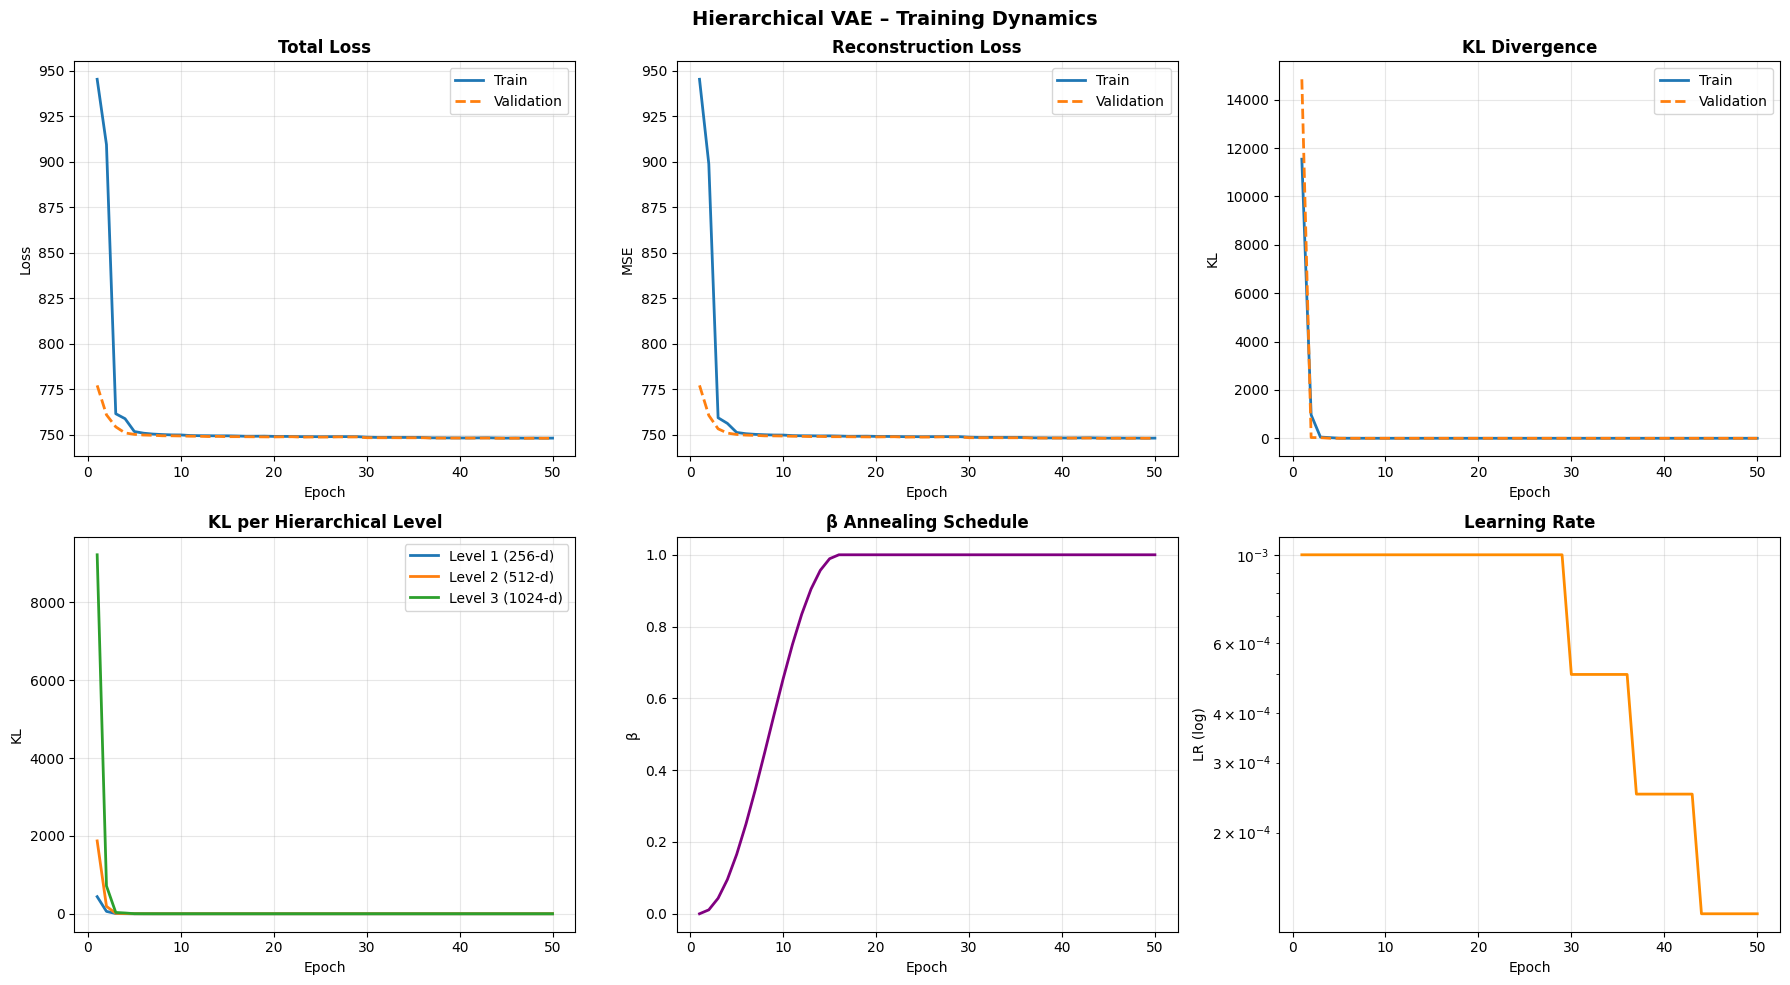

✓ Saved → training_history.png


In [12]:
def plot_training_history(history, save_path="training_history.png"):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Hierarchical VAE – Training Dynamics", fontsize=14, fontweight="bold")

    ep = range(1, len(history["train_loss"]) + 1)

    def _plot(ax, key_train, key_val, title, ylabel):
        ax.plot(ep, history[key_train], label="Train",      lw=2)
        ax.plot(ep, history[key_val],   label="Validation", lw=2, ls="--")
        ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)

    _plot(axes[0,0], "train_loss",  "val_loss",  "Total Loss",         "Loss")
    _plot(axes[0,1], "train_recon", "val_recon", "Reconstruction Loss","MSE")
    _plot(axes[0,2], "train_kl",    "val_kl",    "KL Divergence",      "KL")

    # Per-level KL
    ax = axes[1, 0]
    for lvl, key in enumerate(["kl_l1", "kl_l2", "kl_l3"], 1):
        ax.plot(ep, history[key], label=f"Level {lvl} ({model.latent_dims[lvl-1]}-d)", lw=2)
    ax.set_title("KL per Hierarchical Level", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("KL"); ax.legend(); ax.grid(alpha=0.3)

    # β schedule
    ax = axes[1, 1]
    ax.plot(ep, history["beta"], color="purple", lw=2)
    ax.set_title("β Annealing Schedule", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("β"); ax.grid(alpha=0.3)

    # Learning rate
    ax = axes[1, 2]
    ax.semilogy(ep, history["lr"], color="darkorange", lw=2)
    ax.set_title("Learning Rate", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("LR (log)"); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")


plot_training_history(history)


## Cell 13 – Reload best checkpoint before analysis

In [13]:
ckpt = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✓ Loaded best model  (epoch {ckpt['epoch']+1}, val_loss={ckpt['val_loss']:.4f})")


✓ Loaded best model  (epoch 47, val_loss=748.0386)


## Cell 14 – Extract latent representations from test set

In [14]:
def extract_latents(model, loader, device, max_samples=10_000):
    """
    Run the encoder over a data loader and collect all three latent levels.

    Returns
    -------
    dict with keys 'level1', 'level2', 'level3' → np.ndarray (N, dim)
    """
    model.eval()
    bufs = [[], [], []]
    collected = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting latents"):
            if collected >= max_samples:
                break
            x = batch.to(device, non_blocking=True)
            (z1, z2, z3), _ = model.encode(x)
            for i, z in enumerate([z1, z2, z3]):
                bufs[i].append(z.cpu().numpy())
            collected += len(x)

    latents_dict = {
        "level1": np.concatenate(bufs[0], axis=0)[:max_samples],
        "level2": np.concatenate(bufs[1], axis=0)[:max_samples],
        "level3": np.concatenate(bufs[2], axis=0)[:max_samples],
    }
    for k, v in latents_dict.items():
        print(f"  {k}: {v.shape}")
    return latents_dict


latents_dict = extract_latents(model, test_loader, DEVICE)


Extracting latents:   0%|          | 0/8 [00:00<?, ?it/s]

  level1: (977, 256)
  level2: (977, 512)
  level3: (977, 1024)


## Cell 15 – Intrinsic dimensionality (PCA)

level1 : intrinsic= 220 / 256  (85.9% utilised)
level2 : intrinsic= 394 / 512  (77.0% utilised)
level3 : intrinsic= 610 / 1024  (59.6% utilised)


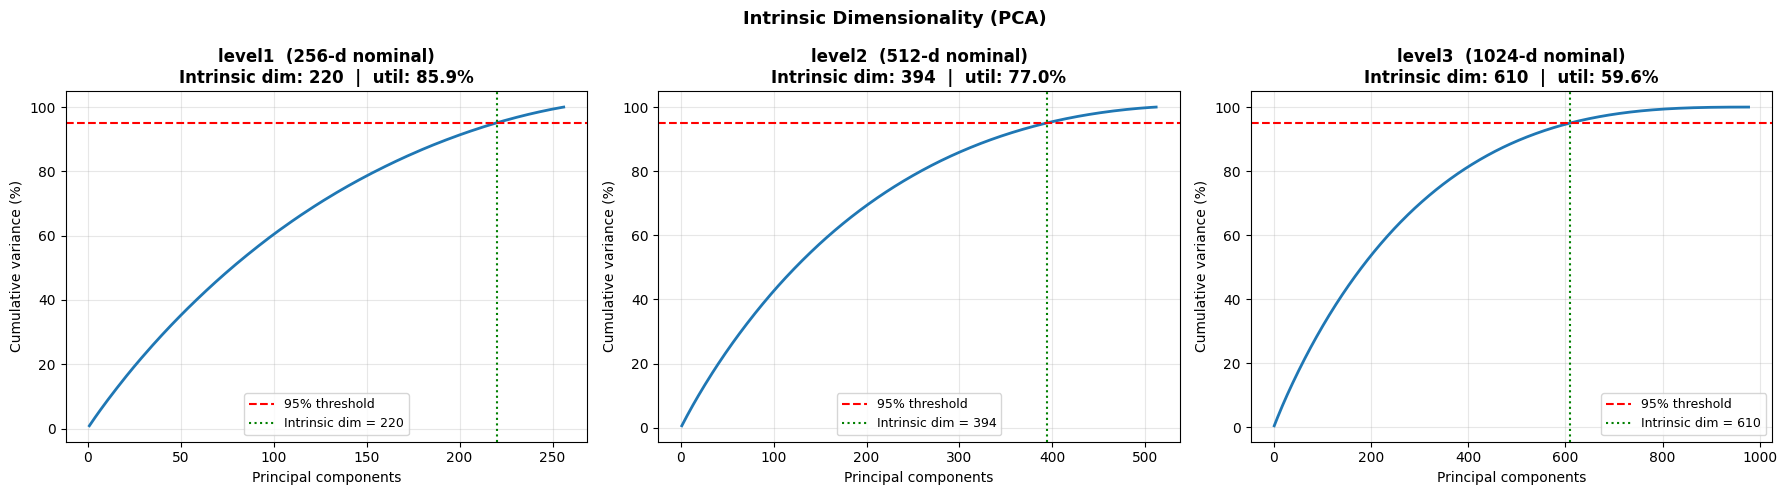

✓ Saved → intrinsic_dimensionality.png


In [15]:
def analyze_intrinsic_dimensionality(latents_dict, threshold=0.95,
                                     save_path="intrinsic_dimensionality.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Intrinsic Dimensionality (PCA)", fontsize=13, fontweight="bold")

    results = {}
    for ax, (name, Z) in zip(axes, latents_dict.items()):
        pca = PCA().fit(Z)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        intrinsic = int(np.searchsorted(cumvar, threshold)) + 1
        util = intrinsic / Z.shape[1] * 100

        results[name] = dict(
            nominal_dim  = Z.shape[1],
            intrinsic_dim= intrinsic,
            utilisation  = util,
        )

        ax.plot(np.arange(1, len(cumvar)+1), cumvar * 100, lw=2)
        ax.axhline(threshold * 100, ls="--", color="red",
                   label=f"{threshold*100:.0f}% threshold")
        ax.axvline(intrinsic, ls=":", color="green",
                   label=f"Intrinsic dim = {intrinsic}")
        ax.set_xlabel("Principal components"); ax.set_ylabel("Cumulative variance (%)")
        ax.set_title(f"{name}  ({Z.shape[1]}-d nominal)\n"
                     f"Intrinsic dim: {intrinsic}  |  util: {util:.1f}%",
                     fontweight="bold")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        print(f"{name:7s}: intrinsic={intrinsic:4d} / {Z.shape[1]}  ({util:.1f}% utilised)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")
    return results


intrinsic_results = analyze_intrinsic_dimensionality(latents_dict)


## Cell 16 – UMAP projections of latent space

UMAP for level1  (256-d → 2-d) …
UMAP for level2  (512-d → 2-d) …
UMAP for level3  (1024-d → 2-d) …


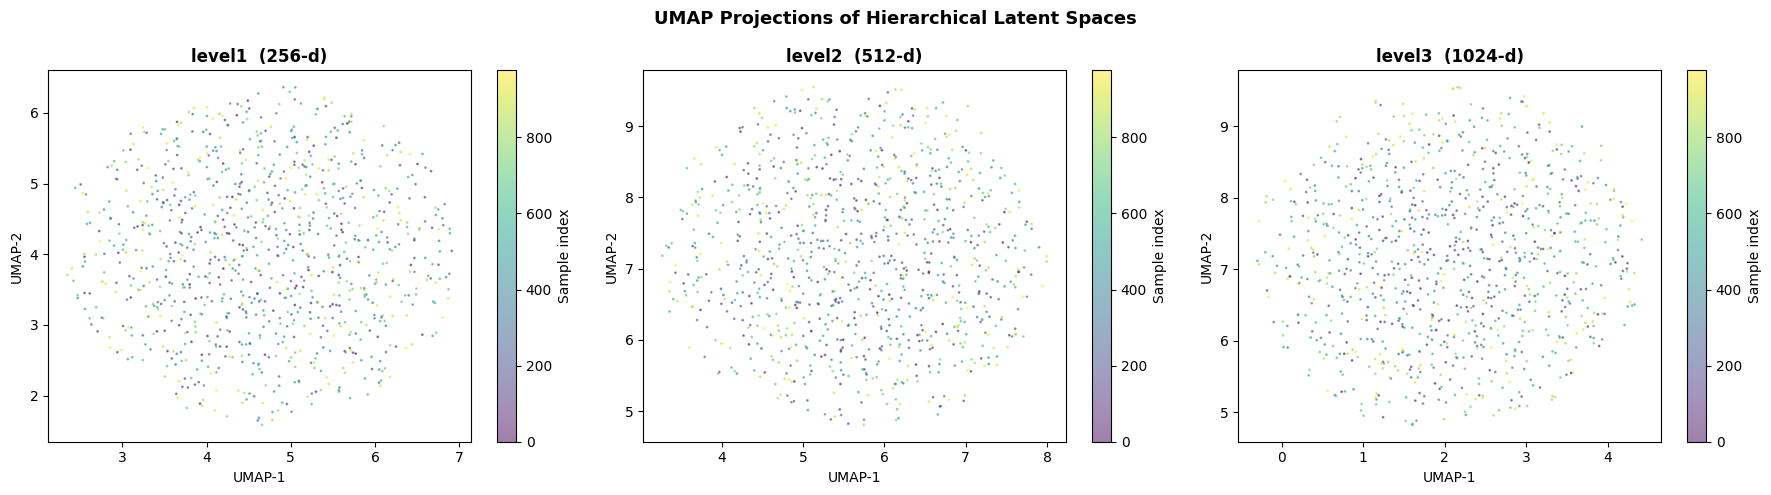

✓ Saved → latent_umap.png


In [16]:
def visualize_latent_umap(latents_dict, n_samples=5_000,
                          save_path="latent_umap.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("UMAP Projections of Hierarchical Latent Spaces",
                 fontsize=13, fontweight="bold")

    for ax, (name, Z) in zip(axes, latents_dict.items()):
        if len(Z) > n_samples:
            idx = np.random.choice(len(Z), n_samples, replace=False)
            Z_sub = Z[idx]
        else:
            Z_sub = Z

        print(f"UMAP for {name}  ({Z_sub.shape[1]}-d → 2-d) …")
        emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric="euclidean", random_state=SEED,
                        verbose=False).fit_transform(Z_sub)

        sc = ax.scatter(emb[:, 0], emb[:, 1],
                        c=np.arange(len(emb)), cmap="viridis",
                        s=1, alpha=0.5, rasterized=True)
        plt.colorbar(sc, ax=ax, label="Sample index")
        ax.set_title(f"{name}  ({Z_sub.shape[1]}-d)", fontweight="bold")
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")


visualize_latent_umap(latents_dict)


## Cell 17 – K-means clustering analysis

Clustering level1 (k=10) …
  level1: silhouette=0.0010  DB=8.6745
Clustering level2 (k=10) …
  level2: silhouette=0.0005  DB=10.6022
Clustering level3 (k=10) …
  level3: silhouette=-0.0034  DB=11.4505


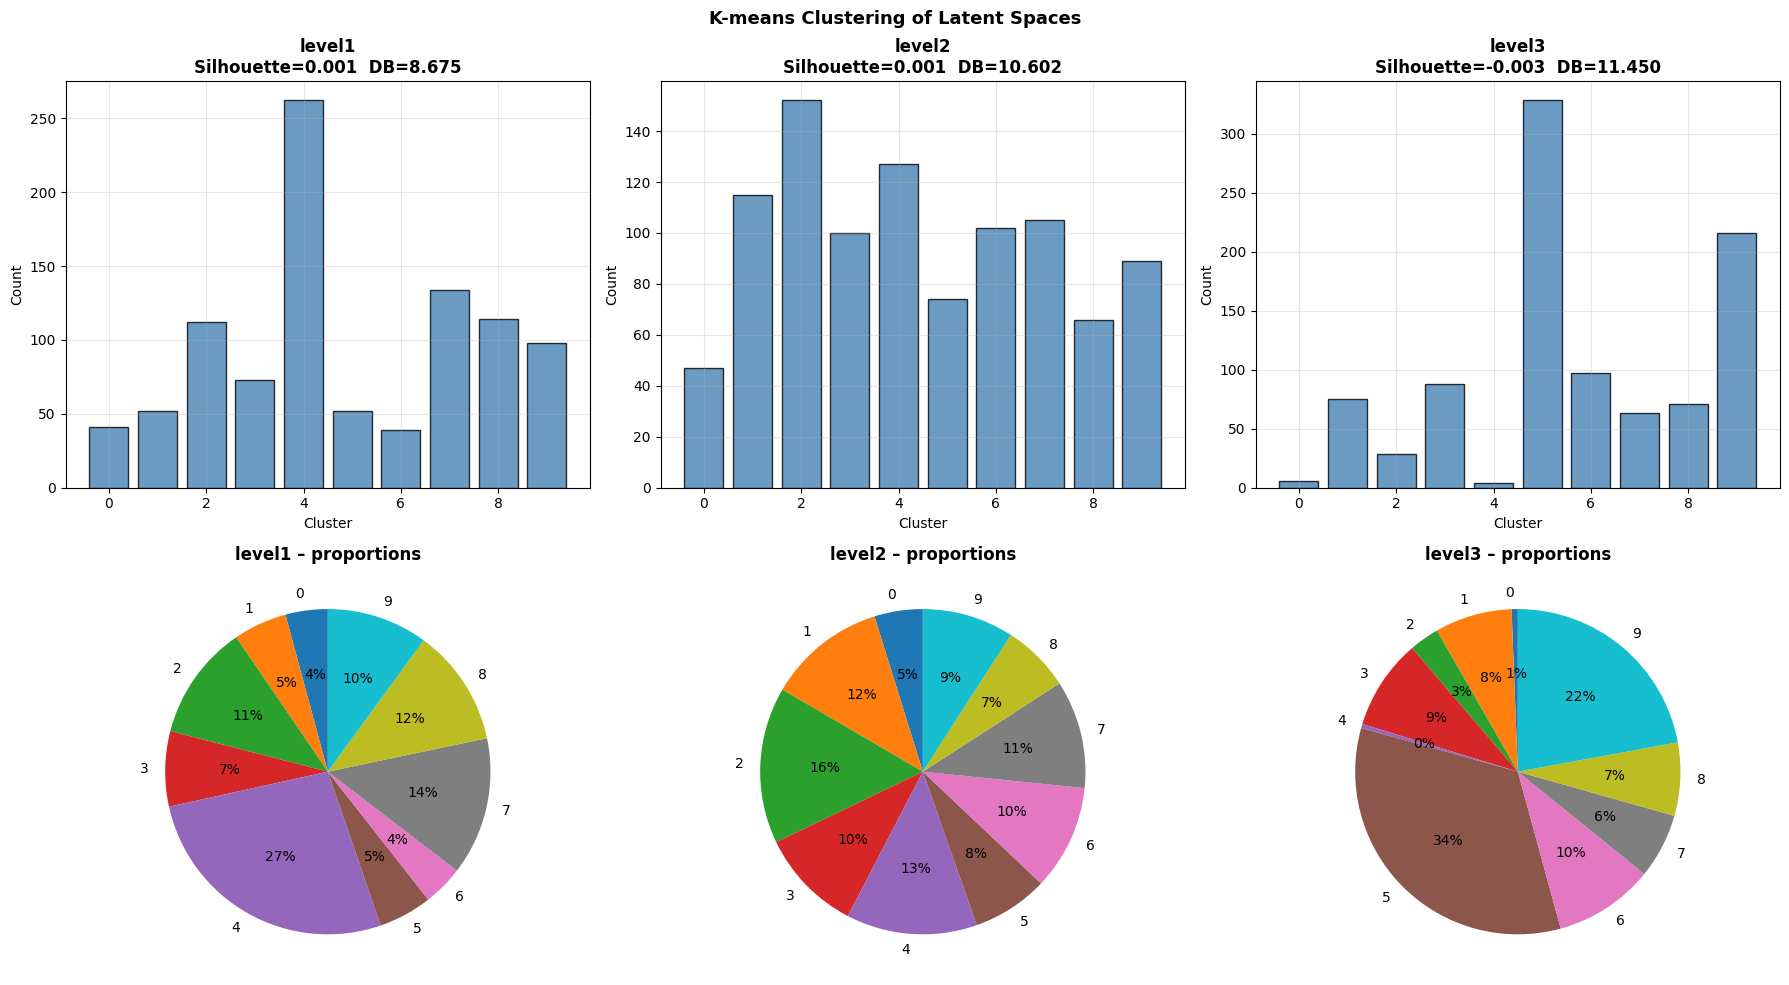

✓ Saved → clustering_analysis.png


In [17]:
def analyze_clustering(latents_dict, n_clusters=10,
                       save_path="clustering_analysis.png"):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("K-means Clustering of Latent Spaces",
                 fontsize=13, fontweight="bold")

    results = {}
    for col, (name, Z) in enumerate(latents_dict.items()):
        print(f"Clustering {name} (k={n_clusters}) …")
        km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
        labels = km.fit_predict(Z)

        sil = silhouette_score(Z, labels, sample_size=min(len(Z), 5000),
                               random_state=SEED)
        db  = davies_bouldin_score(Z, labels)
        results[name] = dict(silhouette=sil, davies_bouldin=db,
                             labels=labels, inertia=km.inertia_)

        # cluster-size bar chart
        ax = axes[0, col]
        vals, counts = np.unique(labels, return_counts=True)
        ax.bar(vals, counts, color="steelblue", alpha=0.8, edgecolor="k")
        ax.set_title(f"{name}\nSilhouette={sil:.3f}  DB={db:.3f}",
                     fontweight="bold")
        ax.set_xlabel("Cluster"); ax.set_ylabel("Count"); ax.grid(alpha=0.3)

        # cluster-size pie
        ax = axes[1, col]
        ax.pie(counts, labels=[str(v) for v in vals],
               autopct="%1.0f%%", startangle=90)
        ax.set_title(f"{name} – proportions", fontweight="bold")

        print(f"  {name}: silhouette={sil:.4f}  DB={db:.4f}")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")
    return results


clustering_results = analyze_clustering(latents_dict)


## Cell 18 – Reconstruction quality evaluation

In [18]:
def evaluate_reconstruction(model, loader, device, n_examples=10):
    """
    Decode test-set sequences and compare them base-by-base to the originals.
    """
    model.eval()
    accuracies = []
    shown = 0

    print("=" * 80)
    print("RECONSTRUCTION QUALITY  (per-base accuracy)")
    print("=" * 80)

    with torch.no_grad():
        for batch in loader:
            if shown >= n_examples:
                break
            x = batch.to(device, non_blocking=True)
            recon, _, _ = model(x)

            for i in range(min(len(x), n_examples - shown)):
                orig_arr  = x[i].cpu().numpy().reshape(4, 1024)
                recon_arr = recon[i].cpu().numpy().reshape(4, 1024)
                orig_seq  = DNAEncoder.decode_one_hot(orig_arr)
                recon_seq = DNAEncoder.decode_one_hot(recon_arr)

                acc = sum(a == b for a, b in zip(orig_seq, recon_seq)) / len(orig_seq)
                accuracies.append(acc)

                print(f"\nSample {shown+1}  accuracy={acc*100:.2f}%")
                print(f"  Original : {orig_seq[:60]}…")
                print(f"  Recon    : {recon_seq[:60]}…")
                shown += 1

    print(f"\nMean accuracy : {np.mean(accuracies)*100:.2f}%")
    print(f"Std  accuracy : {np.std(accuracies)*100:.2f}%")
    return accuracies


reconstruction_accuracies = evaluate_reconstruction(model, test_loader, DEVICE)


RECONSTRUCTION QUALITY  (per-base accuracy)

Sample 1  accuracy=0.00%
  Original : AGGGCTTGTACCGCTAGTACTACTAAGACAATTTCAAATGGGAATATGGCATTATGATAG…
  Recon    : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN…

Sample 2  accuracy=0.00%
  Original : TTGGTCATATATACACGAAATTGAATGGAAATGCGATTCGTTACGAGCTTCTCACATTTG…
  Recon    : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN…

Sample 3  accuracy=0.00%
  Original : AAAGTTAAATCTCTTATACTGGATATTTGTTTAAGATATTAACTGTTGCGCTGTCAGTTA…
  Recon    : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN…

Sample 4  accuracy=0.00%
  Original : AATTCATAAAAATTTCCAGTTCGCGCGATGAGGTTACATTAACATCTTGTAGATGTACAA…
  Recon    : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN…

Sample 5  accuracy=0.00%
  Original : ACATAATGGAAATATTAAATTCGAGTGAGCCCCAGCGAGATCTATGAAATAAGGCTTGGG…
  Recon    : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN…

Sample 6  accuracy=0.00%
  Original : CTCCGTTTTTAGTCCTTGTGTAAATCATAGTACAATA

## Cell 19 – Generate synthetic sequences from prior

In [19]:
def generate_from_prior(model, n=100, device="cpu", temperature=1.0):
    """
    Sample z ~ N(0, temperature²I) at each latent level and decode.

    Returns
    -------
    sequences  : list[str]
    gc_contents: list[float]
    """
    seqs = []; gcs = []
    raw  = model.sample(n, device=device, temperature=temperature).cpu().numpy()

    for i in range(n):
        seq = DNAEncoder.decode_one_hot(raw[i].reshape(4, 1024))
        seqs.append(seq)
        gcs.append(DNAEncoder.gc_content(seq))

    print(f"Generated {n} sequences  temp={temperature}")
    print(f"  GC mean  : {np.mean(gcs):.2f}%   std: {np.std(gcs):.2f}%")
    print(f"  GC range : {np.min(gcs):.2f}% – {np.max(gcs):.2f}%")
    return seqs, gcs


synthetic_seqs, synthetic_gc = generate_from_prior(model, n=200, device=DEVICE)


Generated 200 sequences  temp=1.0
  GC mean  : 0.00%   std: 0.00%
  GC range : 0.00% – 0.00%


## Cell 20 – Generation statistics

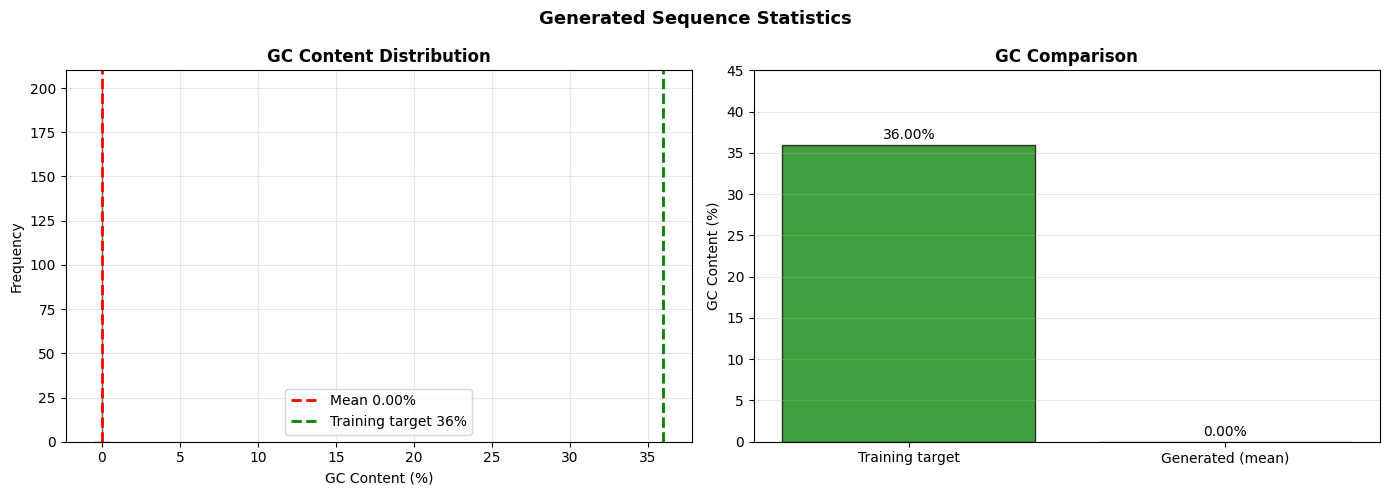

✓ Saved → generation_stats.png


In [20]:
def plot_generation_stats(synthetic_gc, target_gc=36.0,
                          save_path="generation_stats.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Generated Sequence Statistics", fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.hist(synthetic_gc, bins=25, color="steelblue", alpha=0.75, edgecolor="k")
    ax.axvline(np.mean(synthetic_gc), color="red", ls="--", lw=2,
               label=f"Mean {np.mean(synthetic_gc):.2f}%")
    ax.axvline(target_gc, color="green", ls="--", lw=2,
               label=f"Training target {target_gc:.0f}%")
    ax.set_xlabel("GC Content (%)"); ax.set_ylabel("Frequency")
    ax.set_title("GC Content Distribution", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    cats   = ["Training target", "Generated (mean)"]
    vals   = [target_gc, np.mean(synthetic_gc)]
    colors = ["green", "steelblue"]
    bars   = ax.bar(cats, vals, color=colors, alpha=0.75, edgecolor="k")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f"{b.get_height():.2f}%", ha="center", va="bottom")
    ax.set_ylabel("GC Content (%)"); ax.set_ylim(0, max(vals)*1.25)
    ax.set_title("GC Comparison", fontweight="bold"); ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")


plot_generation_stats(synthetic_gc)


## Cell 21 – Comprehensive summary report

In [21]:
def generate_report(history, intrinsic_results, clustering_results,
                    reconstruction_accuracies, synthetic_gc,
                    save_path="final_analysis_report.txt"):

    lines = []
    sep  = "=" * 80
    dash = "-" * 80

    lines += [sep, "HIERARCHICAL VAE – FINAL ANALYSIS REPORT", sep, ""]

    lines += ["1. TRAINING SUMMARY", dash]
    lines += [
        f"   Epochs trained    : {len(history['train_loss'])}",
        f"   Final train loss  : {history['train_loss'][-1]:.4f}",
        f"   Final val   loss  : {history['val_loss'][-1]:.4f}",
        f"   Best  val   loss  : {min(history['val_loss']):.4f}",
        f"   Final recon loss  : {history['train_recon'][-1]:.4f}",
        f"   Final KL          : {history['train_kl'][-1]:.4f}",
        "",
    ]

    lines += ["2. MODEL ARCHITECTURE", dash]
    lines += [
        "   Input dim         : 4096  (1024 bp one-hot)",
        "   Latent dims       : [256, 512, 1024]",
        "   Total latent dim  : 1792",
        f"  Parameters        : {sum(p.numel() for p in model.parameters()):,}",
        "",
    ]

    lines += ["3. INTRINSIC DIMENSIONALITY (95% variance)", dash]
    for name, r in intrinsic_results.items():
        lines.append(f"   {name:7s}: intrinsic={r['intrinsic_dim']:4d}"
                     f" / {r['nominal_dim']}  "
                     f"({r['utilisation']:.1f}% utilised)")
    lines.append("")

    lines += ["4. CLUSTERING (k=10)", dash]
    for name, r in clustering_results.items():
        lines.append(f"   {name:7s}: silhouette={r['silhouette']:.4f}  "
                     f"davies-bouldin={r['davies_bouldin']:.4f}")
    lines.append("")

    lines += ["5. RECONSTRUCTION QUALITY", dash]
    lines += [
        f"   Samples evaluated : {len(reconstruction_accuracies)}",
        f"   Mean accuracy     : {np.mean(reconstruction_accuracies)*100:.2f}%",
        f"   Std  accuracy     : {np.std(reconstruction_accuracies)*100:.2f}%",
        "",
    ]

    lines += ["6. SYNTHETIC GENERATION", dash]
    lines += [
        f"   Sequences generated : {len(synthetic_gc)}",
        f"   Mean GC content     : {np.mean(synthetic_gc):.2f}%",
        f"   Std  GC content     : {np.std(synthetic_gc):.2f}%",
        f"   Training target GC  : 36.00%",
        f"   Delta (|mean-tgt|)  : {abs(np.mean(synthetic_gc)-36):.2f}%",
        "",
    ]

    report = "\n".join(lines)
    print(report)
    with open(save_path, "w") as fh:
        fh.write(report)
    print(f"✓ Saved → {save_path}")
    return report


report_text = generate_report(
    history, intrinsic_results, clustering_results,
    reconstruction_accuracies, synthetic_gc,
)


HIERARCHICAL VAE – FINAL ANALYSIS REPORT

1. TRAINING SUMMARY
--------------------------------------------------------------------------------
   Epochs trained    : 50
   Final train loss  : 748.1270
   Final val   loss  : 748.0401
   Best  val   loss  : 748.0386
   Final recon loss  : 748.1241
   Final KL          : 0.0029

2. MODEL ARCHITECTURE
--------------------------------------------------------------------------------
   Input dim         : 4096  (1024 bp one-hot)
   Latent dims       : [256, 512, 1024]
   Total latent dim  : 1792
  Parameters        : 28,471,808

3. INTRINSIC DIMENSIONALITY (95% variance)
--------------------------------------------------------------------------------
   level1 : intrinsic= 220 / 256  (85.9% utilised)
   level2 : intrinsic= 394 / 512  (77.0% utilised)
   level3 : intrinsic= 610 / 1024  (59.6% utilised)

4. CLUSTERING (k=10)
--------------------------------------------------------------------------------
   level1 : silhouette=0.0010  davies-b

## Cell 22 – Save all artefacts

In [22]:
# ── pickle objects ────────────────────────────────────────────────────────────
for obj, fname in [
    (latents_dict,              "latent_representations.pkl"),
    (clustering_results,        "clustering_results.pkl"),
    (history,                   "training_history.pkl"),
    (intrinsic_results,         "intrinsic_results.pkl"),
    (reconstruction_accuracies, "reconstruction_accuracies.pkl"),
]:
    with open(fname, "wb") as fh:
        pickle.dump(obj, fh)
    size_kb = os.path.getsize(fname) / 1024
    print(f"  ✓ {fname}  ({size_kb:.0f} KB)")

# ── list all output files ─────────────────────────────────────────────────────
FILES = [
    "best_model.pth",
    "training_history.png", "intrinsic_dimensionality.png",
    "latent_umap.png", "clustering_analysis.png", "generation_stats.png",
    "final_analysis_report.txt",
    "latent_representations.pkl", "clustering_results.pkl",
    "training_history.pkl",
]

print("\n" + "=" * 60)
print("OUTPUT FILES")
print("=" * 60)
for f in FILES:
    if os.path.exists(f):
        print(f"  ✓ {f}  ({os.path.getsize(f)/1024:.0f} KB)")
    else:
        print(f"  ✗ {f}  (not found)")
print("=" * 60)


  ✓ latent_representations.pkl  (6839 KB)
  ✓ clustering_results.pkl  (12 KB)
  ✓ training_history.pkl  (5 KB)
  ✓ intrinsic_results.pkl  (0 KB)
  ✓ reconstruction_accuracies.pkl  (0 KB)

OUTPUT FILES
  ✓ best_model.pth  (333704 KB)
  ✓ training_history.png  (177 KB)
  ✓ intrinsic_dimensionality.png  (121 KB)
  ✓ latent_umap.png  (328 KB)
  ✓ clustering_analysis.png  (211 KB)
  ✓ generation_stats.png  (75 KB)
  ✓ final_analysis_report.txt  (2 KB)
  ✓ latent_representations.pkl  (6839 KB)
  ✓ clustering_results.pkl  (12 KB)
  ✓ training_history.pkl  (5 KB)


## Cell 23 – Download results (Kaggle / Colab)

In [23]:
import sys, os

IN_COLAB  = "google.colab" in sys.modules or "COLAB_GPU" in os.environ
IN_KAGGLE = os.path.exists("/kaggle/working")

FILES = [
    "best_model.pth",
    "training_history.png", "intrinsic_dimensionality.png",
    "latent_umap.png", "clustering_analysis.png", "generation_stats.png",
    "final_analysis_report.txt",
]

if IN_COLAB:
    from google.colab import files as colab_files
    for f in FILES:
        if os.path.exists(f):
            colab_files.download(f)
            print(f"  ↓ {f}")
        else:
            print(f"  ✗ {f} not found")

elif IN_KAGGLE:
    print("Kaggle: files written to /kaggle/working/ – use the Output tab to download.")
    for f in FILES:
        exists = os.path.exists(f)
        mark = "✓" if exists else "✗"
        print(f"  {mark} {f}")

else:
    print("Local environment – files saved to current directory:")
    for f in FILES:
        if os.path.exists(f):
            print(f"  ✓ {f}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓ generation_stats.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ final_analysis_report.txt
